In [9]:
import numpy as np 
import pandas as pd
from src import utils, redcells, db
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import clear_output
from pathlib import Path
%matplotlib inline
%load_ext autoreload
%autoreload 2
ROOT_PATH = "Z:/data/PROC"
RET_PATH = "D:/retinotopy/aligned_xy/behav"
MDL_PATH = "C:/Users/labadmin/Documents/category-neural/data"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
sessions_to_add = []
sessions_to_add.append({'mname': 'VGa9', 'datexp': '2025_11_07', 'blk':'3','session': 'first training', 'round_id': 1, 'recording': True})

obtain red cells labels: (ONLY RUN ONCE)

In [5]:
!python ../src/redcells.py

RED CHANNEL: selected Directory: Y:/DATA/VGa9/2025_11_07/1
GREEN CHANNEL: selected Directory: Z:/data/PROC/VGa9/2025_11_07/3/suite2p
Y:\DATA\VGa9\2025_11_07\1\*json ['Y:\\DATA\\VGa9\\2025_11_07\\1\\ops.json']
NOTE: nplanes 2 nrois 10 => ops['nplanes'] = 20
tif
** Found 1 tifs - converting to binary **
Y:\DATA\VGa9\2025_11_07\1\suite2p\plane0\ops.npy
>>>> registering PLANE 0
Y:\DATA\VGa9\2025_11_07\1\suite2p\plane0\ops.npy Y:\DATA\VGa9\2025_11_07\1\suite2p\plane0\data.bin
registering two channels
Registered 159/159 in 3.60s
Second channel, Registered 159/159 in 1.46s
Y:\DATA\VGa9\2025_11_07\1\suite2p\plane0\ops.npy
>>>> INTENSITY RATIO estimating red cells
Y:\DATA\VGa9\2025_11_07\1\suite2p\plane1\ops.npy
>>>> INTENSITY RATIO estimating red cells
Y:\DATA\VGa9\2025_11_07\1\suite2p\plane2\ops.npy
>>>> INTENSITY RATIO estimating red cells
Y:\DATA\VGa9\2025_11_07\1\suite2p\plane3\ops.npy
>>>> INTENSITY RATIO estimating red cells
Y:\DATA\VGa9\2025_11_07\1\suite2p\plane4\ops.npy
>>>> INTENSITY

Create object

In [3]:
name, datexp, blk = sessions_to_add[0]["mname"], sessions_to_add[0]["datexp"], sessions_to_add[0]["blk"]
print(f"Processing mouse {name}, datexp {datexp}, block {blk}")

Processing mouse VGa9, datexp 2025_11_07, block 3


In [10]:
m = utils.load_mouse(name, datexp, blk, load_neurons=True, interp_behav=True, load_retinotopy=True, return_iscell=True,
                      data_path=ROOT_PATH, ret_path=RET_PATH,  mdl_path=MDL_PATH, opt_tlag = 1)
frameselector = utils.get_frameselector(m)
istim_df = pd.DataFrame(m._timeline['istim'], columns=['istim'])
istim_df["trial_no"] = np.arange(1, len(istim_df)+1).astype(float)
m.frameselector = (frameselector.reset_index()
    .rename(columns = {'index':'frame'})
    .merge(istim_df, left_on='trial_no', right_on='trial_no', how='left')
    .set_index('frame'))

green_channel = Path(ROOT_PATH).joinpath(name, datexp, blk, "suite2p")
m.isred = redcells.get_redcells(green_channel)

Checking if model object exists ...
Timeline with fname: Timeline_VGa9_2025_11_07_3.mat not found, trying with fname: VGa9_2025_11_07_3.mat 
Timeline file is in v7.3 format, loading with h5py
number of recording planes: 20
planes: 20


100%|██████████| 20/20 [05:26<00:00, 16.33s/it]


Loading retinotopy data from D:\retinotopy\aligned_xy\behav\VGa9_2025_11_07_3_behav.npz
nrecording_rois: 20
(28339, 2)


cleaning of variables this code assumes that the retinotopy files are already filtered for only cells:

In [ ]:
cell_mask = (m._is_cell[:,0]).astype(bool) 
noise_mask = (m._snr>=.25).astype(bool)
condition = cell_mask * noise_mask
#retinotopy files:
snr_reti = m._snr[cell_mask]
noise_mask = (snr_reti>=.25).astype(bool)
m.iarea = m.iarea[noise_mask]
m.iregion = m.iregion[noise_mask]
m.xy_t = m.xy_t[noise_mask]
#suite2p files:
m.isred = m.isred[condition]
m._spks = m._spks[condition]
m._xpos = m._xpos[condition]
m._ypos = m._ypos[condition]
m._iplane = m._iplane[condition]
m._snr = m._snr[condition]

In [25]:
print(m.isred.shape)

(23437, 2)


create interpolated spks to corridor and same object:

In [ ]:
m.trial_dict = utils.get_trialno_bytype(m.frameselector)
for zscored in [True]: ##[True, False]:
    print("saving zscored version" if zscored else "saving not zscored version") 
    m.interp_spks = utils.interp_spks_by_corridorlength(m, m.frameselector, z = zscored, corridor_length=400)
    save_path = r"D:\mouseobj" if zscored else r"D:\mouseobj\notz"
    utils.compute_dprime(m, discrimination_region = (0,100), corridor_length = 400, nogray = False)
    utils.save_mouse(m, compressed=False, mdl_path=save_path)

saving zscored version
4 9522
interpolating 23437 neurons, 9519 frames to
the vector of distance with shape: (9519,)
neurons: 23437, trials: 399, corridor length: 400
dprime saved in MouseObject.train_dp (neurons) using even trials
Creating directory D:\mouseobj\VGa9\2025_11_07\3
Mouse object saved to D:\mouseobj\VGa9\2025_11_07\3


Compute coding dirs:

In [29]:
areas = ["V1", "medial", "lateral", "anterior"]
ctypes = ["exc", "inh"]
ntrialtypes = 4
corridor_length = 400

def select_neurons(m1, area: str, celltype:str, dprime = None, dptsh=95):
    ia = utils.get_region_idx(m1.iarea, area)
    assert celltype in ['exc', 'inh'], "celltype must be either 'exc' or 'inh'"
    selected_type = np.logical_not(m1.isred[:,0]).astype(bool) if celltype == 'exc' else m1.isred[:,0].astype(bool)
    if dprime is None:
        pstv_tsh, ngtv_tsh = utils.get_dp_thresholds(m1.train_dp[ia*selected_type], tsh=dptsh) #tresh based on the area
    else:
        pstv_tsh, ngtv_tsh = utils.get_dp_thresholds(dprime[ia*selected_type], tsh=dptsh)
    prefer_r = (m1.train_dp>=pstv_tsh)
    prefer_nr = (m1.train_dp<=ngtv_tsh)
    area_prefer_r = prefer_r * ia * selected_type
    area_prefer_nr = prefer_nr * ia * selected_type
    return area_prefer_r, area_prefer_nr, selected_type, ia

In [34]:
main_dir = Path(f"../data")
main_dir = main_dir.joinpath(name,datexp, blk)
cds = np.empty((ntrialtypes, len(areas), len(ctypes), corridor_length)) # mice, ttype, areas, cell types, positions
protA = m.trial_dict["rewarded"][1::2]
protB = m.trial_dict["non rewarded"][1::2]
restA = m.trial_dict["rewarded test"]
restB =  m.trial_dict["non rewarded test"]
## Dprime selection trials
trial_split = {"rewarded": protA, "non rewarded": protB, "rewarded test": restA, "non rewarded test": restB}
for ia, area in enumerate(["V1", "medial", "lateral", "anterior"]):
    for ct, c_type in enumerate(["exc", "inh"]):
        a_prefer, b_prefer, _ , _ = select_neurons(m, area, c_type)
        cd = m.interp_spks[a_prefer].mean(0) - m.interp_spks[b_prefer].mean(0)
        for it, trials in enumerate(trial_split.values()):
            cds[it, ia, ct] = cd[trials,:].mean(0)
# if a folder for the session does not exist, create it, and stack the cds to the previous ones
if not main_dir.exists():
    main_dir.mkdir(parents=True)
np.save(main_dir/"cod_dirs_0_100.npy", cds)

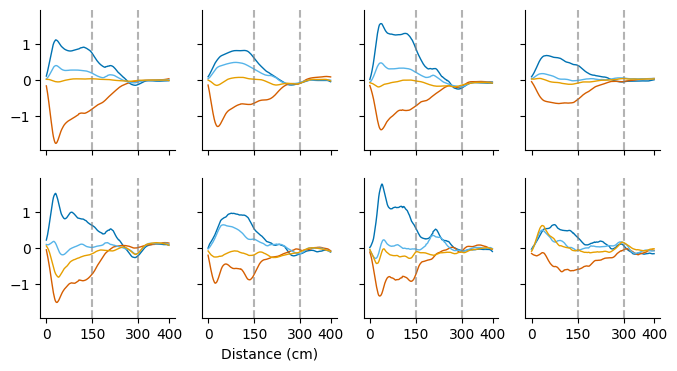

In [45]:
import seaborn as sns
trial_type_palette = ['#0072B2', '#D55E00', '#56B4E9', '#E69F00']
fig, ax = plt.subplots(2, 4, figsize=(8, 4), sharex=True, sharey=True)
ax[-1,1].set_xlabel('Distance (cm)')
ax[-1,1].set_xticks([0, 150,300, 400])
for ttype in range(4):
    for a, area in enumerate(areas):
        for ctype in range(2):
            ax[ctype, a].plot(cds[ttype, a, ctype], color=trial_type_palette[ttype], linewidth=1)
            ax[ctype, a].axvline(x=150, color='gray', linestyle='--', alpha=0.2)
            ax[ctype, a].axvline(x=300, color='gray', linestyle='--', alpha=0.2)
sns.despine()

get cd gi

In [ ]:
pos = 100
gis = np.zeros((4, 2))
dis = np.zeros((4, 2))
gen = np.zeros((4, 2))
avgs_coding_dirs = cds[:,:,:,:pos].mean(-1) #mouse, ttype, area, cell type, positions
for area in range(4):
    for cell_type in range(2):
        gen[area, cell_type] = avgs_coding_dirs[2,area,cell_type] - avgs_coding_dirs[3,area,cell_type]
        dis[area, cell_type] = avgs_coding_dirs[0,area,cell_type] - avgs_coding_dirs[1,area,cell_type]
        if (dis[area, cell_type] < 0) and (gen[area, cell_type] < 0):
            gis[area, cell_type] = np.abs(gen[area, cell_type]) / np.abs(dis[area, cell_type]) * -1
        else:
            gis[area, cell_type] = gen[area, cell_type] / dis[area, cell_type]
gis

array([[ 0.13866994,  0.22646143],
       [ 0.26201097,  0.479788  ],
       [ 0.19117807,  0.10775662],
       [ 0.11966313, -0.0389379 ]])

In [54]:
m = utils.load_mouse(name, datexp, blk, load_neurons=True, interp_behav=True, load_retinotopy=True, mdl_path=r"D:\mouseobj")

Checking if model object exists ...
Loading mouse object from D:\mouseobj\VGa9\2025_11_07\3
Existing mouse object has the following attributes:
dict_keys(['name', 'datexp', 'blk', 'data_path', '_timeline', '_data_var', '_settings', '_timestamps', '_trial_info', '_spks', '_ypos', '_xpos', '_iplane', '_stat', '_ops', '_snr', '_is_cell', 'xy_t', 'iarea', 'iregion', 'outline', 'frameselector', 'isred', 'interp_spks', 'train_dp', 'trial_dict'])


In [55]:
from scipy.stats import zscore

def sig_variance(resp, stimid, zscore = False):
    # this function computers signal variance based on repeated presentations of the same stimuli
    # if you have more than two repeats, this can take advantage of that (equivalent to forming all pairs of repeats)

    # resp = (neurons, #stimuli)
    # stimid = (#stimuli)

    # example cc = sig_variance(resp, stimid)

    iunq = np.unique(stimid)
    if zscore:
        R = zscore(resp, 1)
    else:
        R = resp
    NN = resp.shape[0]
    cc = np.zeros(NN,)    
    nsum = 0
    for j in range(len(stimid)):
        iss = stimid==stimid[j]
        if iss.sum()<2:
            continue;
        cc += (R[:, j] * (R[:, iss].sum(1) - R[:, j])) / (iss.sum()-1)
        nsum += 1 
    if nsum<2:
        raise ValueError('Found %d stimuli with at least two repeats. Requires at least 2.'%nsum)
    cc /= nsum
    return cc

def filter_neurons(m, area, celltype):
        try:
            ia = utils.get_region_idx(m.iarea, area)
        except:
            AssertionError("area must be 'V1', 'medial', 'lateral' or 'anterior'")
        if celltype == "Pyr":
            selected_type = np.logical_not(m.isred[:,0]).astype(bool)
        elif celltype == "Int":
            selected_type = m.isred[:,0].astype(bool)
        else:
            AssertionError("celltype must be 'Pyr' or 'Int' or None")
        
        selection = ia * selected_type
        prop = selection.sum() / ia.sum()
        return selection, prop

def get_istim_matrix(m, area: str, celltype: str, cc_tsh: float = 0.1) -> np.ndarray:
    selection, _ = filter_neurons(m, area, celltype)
    # ensure column exists (zero-based, as created above)
    if 'stim_id_matrix' not in m.frameselector.columns:
        mask_B = m.frameselector['trial_type'].isin(['non rewarded', 'non rewarded test'])
        base = m.frameselector['istim'].astype('Int64') - 1  # zero-based
        m.frameselector['stim_id_matrix'] =np.where(~mask_B, base, base + 51)

    # per-trial response over first 100 positions
    per_trial_resp = m.interp_spks[:, :, :100].mean(2)  # (neurons, trials)
    # get stim ids
    stim_ids = []
    for tn in m.frameselector['trial_no'].unique():
        stim_ids.append(m.frameselector.loc[m.frameselector['trial_no'] == tn, 'stim_id_matrix'].values[0])
    stim_ids = np.array(stim_ids)
    cc = sig_variance(per_trial_resp, stim_ids)
    per_trial_resp = per_trial_resp[selection, :]  # filter neurons
    cc_region = cc[selection]
    sig_neurons = per_trial_resp[cc_region > cc_tsh]
    nneurons = sig_neurons.shape[0]
    id_responses = np.full((nneurons, 102, 2), np.nan, dtype=float)
    # build responses by stim id (0..101)
    stim_vals = m.frameselector['stim_id_matrix']
    for idx in range(102):
        mask = (stim_vals == idx)
        if mask.any():
            trials = m.frameselector.loc[mask, 'trial_no'].dropna().unique().astype(int) - 1
            if trials.size >= 2:
                id_responses[:, idx, 0] = sig_neurons[:, trials[0]]
                id_responses[:, idx, 1] = sig_neurons[:, trials[1]]
    print(id_responses.shape)
    id_responses = zscore(id_responses, axis=1, nan_policy='omit') #across textures
    return id_responses

def get_rsm(stim_mtx: np.ndarray) -> np.ndarray:
    from itertools import combinations
    pairs = list(combinations(np.arange(102),2))
    representation_matrix = np.ones((102,102)) * np.nan
    for pair in pairs:
        instance_a = stim_mtx[:,pair[0],:]
        instance_b = stim_mtx[:,pair[1],:]
        if np.isnan(instance_a).all() or np.isnan(instance_b).all():
            continue
        fh_neurons = instance_a.mean(axis=1)
        sh_neurons = instance_b.mean(axis=1)
        representation_matrix[pair[0],pair[1]] = np.corrcoef(fh_neurons, sh_neurons)[0,1]
        representation_matrix[pair[1],pair[0]] = np.corrcoef(fh_neurons, sh_neurons)[0,1]
    return representation_matrix

def plot_sim_matrix(ax, representation_matrix):
    sns.heatmap(representation_matrix, cmap='coolwarm', center=0, cbar=False, ax=ax)
    ax.axvline(50.7, color='k', linestyle='--')
    ax.axhline(50.7, color='k', linestyle='--')
    ax.text(-12, 35, 'Category A', fontsize=12, rotation=90)
    ax.text(-12, 85, 'Category B', fontsize=12, rotation=90)
    ax.text(15, -2, 'Category A', fontsize=12)
    ax.text(65, -2, 'Category B', fontsize=12)

(6900, 102, 2)


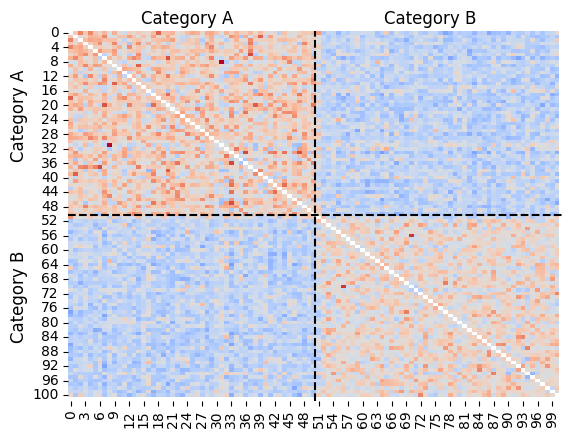

In [59]:
stim_mtx = get_istim_matrix(m, area='V1', celltype='Pyr', cc_tsh=0.1)
rsm = get_rsm(stim_mtx)
plot_sim_matrix(plt.gca(), rsm)

In [62]:
gi_form1 = np.empty((4, 2))
gi_form2 = np.empty((4, 2))

In [63]:
def get_cd_gi(rsm: np.ndarray):
    cat_A = np.nanmean(rsm[:51, :51])
    cat_B = np.nanmean(rsm[51:, 51:])
    intercat = np.nanmean(rsm[:51, 51:])
    gi_1 = (cat_A + cat_B - 2*intercat)
    gi_2 = np.mean([cat_A, cat_B]) - intercat
    return gi_1, gi_2   

In [66]:
ctypes = ["Pyr", "Int"]
gi_form1 = np.empty((4, 2))
gi_form2 = np.empty((4, 2))
for a, area in enumerate(areas):
    for ct, celltype in enumerate(ctypes):
        stim_mtx = get_istim_matrix(m, area=area, celltype=celltype, cc_tsh=0.1)
        rsm = get_rsm(stim_mtx)
        gi_1, gi_2 = get_cd_gi(rsm)
        gi_form1[a, ct] = gi_1
        gi_form2[a, ct] = gi_2

(6900, 102, 2)
(318, 102, 2)
(1956, 102, 2)
(86, 102, 2)
(1611, 102, 2)
(63, 102, 2)
(961, 102, 2)
(57, 102, 2)


In [67]:
gi_form1

array([[0.14018659, 0.21003094],
       [0.32963435, 0.38851329],
       [0.13865493, 0.17898413],
       [0.07572394, 0.0831767 ]])

In [68]:
gi_form2

array([[0.07009329, 0.10501547],
       [0.16481717, 0.19425665],
       [0.06932747, 0.08949206],
       [0.03786197, 0.04158835]])

In [69]:
def get_sig_neurons(m, area: str, celltype: str, cc_tsh: float = 0.1) -> np.ndarray:
    selection, _ = filter_neurons(m, area, celltype)
    # ensure column exists (zero-based, as created above)
    if 'stim_id_matrix' not in m.frameselector.columns:
        mask_B = m.frameselector['trial_type'].isin(['non rewarded', 'non rewarded test'])
        base = m.frameselector['istim'].astype('Int64') - 1  # zero-based
        m.frameselector['stim_id_matrix'] =np.where(~mask_B, base, base + 51)

    # per-trial response over first 100 positions
    per_trial_resp = m.interp_spks[:, :, :100].mean(2)  # (neurons, trials)
    # get stim ids
    stim_ids = []
    for tn in m.frameselector['trial_no'].unique():
        stim_ids.append(m.frameselector.loc[m.frameselector['trial_no'] == tn, 'stim_id_matrix'].values[0])
    stim_ids = np.array(stim_ids)
    cc = sig_variance(per_trial_resp, stim_ids)
    per_trial_resp = per_trial_resp[selection, :]  # filter neurons
    cc_region = cc[selection]
    sig_neurons = per_trial_resp[cc_region > cc_tsh]
    nneurons = sig_neurons.shape[0]
    sig_neurons = zscore(sig_neurons, axis=1, nan_policy='omit') #across textures
    return sig_neurons, nneurons




def get_rsm_trial(sig_neurons: np.ndarray) -> np.ndarray:
    n_trials = sig_neurons.shape[1]
    S = np.full((n_trials, n_trials), np.nan)
    #from scipy.stats import pearsonr
    for i in range(n_trials):
        vi = sig_neurons[:, i]
        for j in range(i, n_trials):  # start from i to skip lower triangle
            vj = sig_neurons[:, j]
            r = np.corrcoef(vi, vj)[0, 1]
            S[i, j] = r

    i_upper = np.triu_indices(n_trials, 1)
    S[i_upper[1], i_upper[0]] = S[i_upper]
    return S

def get_trials_per_stim(m):
    trials_per_stim = []
    for tn in pd.Series(m.frameselector['stim_id_matrix'].unique()).sort_values().unique():
        trials_per_stim.append(m.frameselector.loc[m.frameselector['stim_id_matrix'] == tn, 'trial_no'].unique().astype(int)- 1)
    trials_per_stim = np.array(trials_per_stim, dtype=object)
    return trials_per_stim

def clean_rsm_trial(S: np.ndarray, sig_neurons: np.ndarray, trials_per_stim: np.ndarray) -> np.ndarray:
    n_trials = sig_neurons.shape[1]
    S_cleaned = S.copy()
    for stim, trials in enumerate(trials_per_stim):
        if len(trials) == 2:
            # create masks 
            S_cleaned[trials[0], trials[1]] = np.nan
            S_cleaned[trials[1], trials[0]] = np.nan
    # set diagonal to nan
    diagnonal_indices = np.arange(n_trials)
    S_cleaned[diagnonal_indices, diagnonal_indices] = np.nan
    return S_cleaned

def filter_rsm(rsm, trial_cond1, trial_cond2):
    filtered = np.concatenate((trial_cond1, trial_cond2))
    return rsm[np.ix_(filtered, filtered)]

def compute_iindex_cond(rsm_filtered: np.ndarray, cond1) -> float:
    intraA = np.nanmean(rsm_filtered[:len(cond1), :len(cond1)])
    intraB = np.nanmean(rsm_filtered[len(cond1):, len(cond1):])
    intercat = np.nanmean(rsm_filtered[:len(cond1), len(cond1):])
    return intraA, intraB, intercat

In [71]:
celltype

'Int'

In [74]:
m.trial_dict

{'rewarded': array([  0,  17,  24,  28,  30,  31,  46,  48,  49,  51,  53,  55,  56,
         63,  64,  65,  69,  71,  72,  74,  77,  78,  83,  85,  94, 103,
        112, 114, 117, 121, 127, 128, 133, 136, 148, 152, 155, 158, 159,
        163, 174, 184, 186, 192, 201, 210, 217, 221, 229, 232, 233, 234,
        238, 240, 241, 242, 248, 249, 251, 260, 261, 270, 271, 274, 275,
        277, 279, 283, 293, 296, 297, 302, 304, 310, 311, 316, 317, 318,
        319, 323, 328, 331, 338, 341, 344, 346, 347, 349, 350, 352, 354,
        368, 369, 370, 377, 381, 382, 389, 393, 395]),
 'non rewarded': array([  1,   9,  12,  15,  16,  18,  20,  27,  37,  41,  44,  57,  62,
         66,  68,  76,  80,  82,  87,  92,  98,  99, 102, 106, 109, 111,
        115, 122, 124, 126, 129, 131, 132, 135, 139, 141, 147, 160, 162,
        164, 167, 175, 176, 177, 179, 183, 191, 193, 194, 197, 199, 203,
        211, 212, 214, 219, 222, 227, 228, 235, 236, 243, 252, 253, 256,
        264, 265, 268, 269, 272, 281, 288

In [75]:
rows = []
celltype = ["Pyr", "Int"]
mask_B = m.frameselector['trial_type'].isin(['non rewarded', 'non rewarded test'])
base = m.frameselector['istim'].astype('Int64') - 1  # zero-based
m.frameselector['stim_id_matrix'] = np.where(~mask_B, base, base + 51)
for ia, area in enumerate(areas):
    for ic, ctype in enumerate(celltype):
        print(f"Processing area: {area}, celltype: {ctype}")
        sig_neurons, nneurons = get_sig_neurons(m, area=area, celltype=ctype, cc_tsh=0.1)
        rsm = get_rsm_trial(sig_neurons)
        trials_per_stim = get_trials_per_stim(m)
        rsm_cleaned = clean_rsm_trial(rsm, sig_neurons, trials_per_stim)
        #prot
        filtered_rsm_prot = filter_rsm(rsm_cleaned, m.trial_dict["rewarded"], m.trial_dict["non rewarded"])
        intraA_prot, intraB_prot, intercat_prot = compute_iindex_cond(filtered_rsm_prot, m.trial_dict["rewarded"])
        #nonprot
        filtered_rsm_nonprot = filter_rsm(rsm_cleaned, m.trial_dict["rewarded test"], m.trial_dict["non rewarded test"])
        intraA_nonprot, intraB_nonprot, intercat_nonprot = compute_iindex_cond(filtered_rsm_nonprot, m.trial_dict["rewarded test"])
        rows.append({
            "mouse": name,
            "area": area,
            "celltype": ctype,
            "Invariance_cds": gis[ia, ic],
            "Invariance_stim_form1": gi_form1[ia, ic],
            "Invariance_stim_form2": gi_form2[ia, ic],
            "Invariance_prot_form1": intraA_prot + intraB_prot - (2 * intercat_prot),
            "Invariance_prot_form2": np.mean([intraA_prot, intraB_prot]) - intercat_prot,
            "Invariance_nonprot_form1": intraA_nonprot + intraB_nonprot - (2 * intercat_nonprot),
            "Invariance_nonprot_form2": np.mean([intraA_nonprot, intraB_nonprot]) - intercat_nonprot
        })
gis_df = pd.DataFrame(rows)

Processing area: V1, celltype: Pyr
Processing area: V1, celltype: Int
Processing area: medial, celltype: Pyr
Processing area: medial, celltype: Int
Processing area: lateral, celltype: Pyr
Processing area: lateral, celltype: Int
Processing area: anterior, celltype: Pyr
Processing area: anterior, celltype: Int


In [76]:
gis_df

,mouse,area,celltype,Invariance_cds,Invariance_stim_form1,Invariance_stim_form2,Invariance_prot_form1,Invariance_prot_form2,Invariance_nonprot_form1,Invariance_nonprot_form2
0,VGa9,V1,Pyr,0.138670,0.140187,0.070093,0.669720,0.334860,0.091381,0.045691
1,VGa9,V1,Int,0.226461,0.210031,0.105015,0.661935,0.330968,0.118284,0.059142
2,VGa9,medial,Pyr,0.262011,0.329634,0.164817,0.609301,0.304650,0.194118,0.097059
3,VGa9,medial,Int,0.479788,0.388513,0.194257,0.502567,0.251284,0.240721,0.120360
4,VGa9,lateral,Pyr,0.191178,0.138655,0.069327,0.769755,0.384878,0.086986,0.043493
5,VGa9,lateral,Int,0.107757,0.178984,0.089492,0.829129,0.414565,0.095104,0.047552
6,VGa9,anterior,Pyr,0.119663,0.075724,0.037862,0.423212,0.211606,0.050064,0.025032
7,VGa9,anterior,Int,-0.038938,0.083177,0.041588,0.248579,0.124289,0.054816,0.027408
